In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
def add_colorbar(fig, ax, im, label=None):
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    axins = inset_axes(ax,
                       width="5%",
                       height="100%",
                       loc="lower left",
                       bbox_to_anchor=(1.00, 0., 1.05, 1),
                       bbox_transform=ax.transAxes,
                       borderpad=0)
    cbar = fig.colorbar(im, cax=axins)
    # cbar.ax.set_yticklabels(cbar.ax.get_yticks(), fontsize="medium")
    if label is not None:
        cbar.set_label(label)
    return cbar

In [20]:
nz = 28
nw = 201

In [30]:
I = np.loadtxt("I_for_S_pert_B1000G_nodiffuse.txt").T.reshape(4, nz, nw, order="F")
# # I = np.loadtxt("I.txt").T.reshape(4, nz, nw, order="F")
I.shape

(4, 57, 201)

In [28]:
I0 = {}
Icont = {}
for B in [0, 1000, 3000]:
    I0[B] = np.loadtxt(f"I_nonperturbed_B{B:05d}G_nodiffuse.txt").T.reshape(4, nz, nw, order="F")
    # I0 = np.loadtxt("I_nonperturbed_B1000G_diffuse.txt").T.reshape(4, nz, nw, order="F")
    Icont[B] = I0[B][0,-1,-1]
    # I0[B].shape

In [29]:
Ip = {}
for B in [0, 1000, 3000]:
    Ip[B] = np.loadtxt(f"I_perturbed_B{B:05d}G_nodiffuse.txt").T.reshape(4, nz, nw, order="F")
    # Ip = np.loadtxt("I_perturbed_B1000G_diffuse.txt").T.reshape(4, nz, nw, order="F")
    # Ip.shape

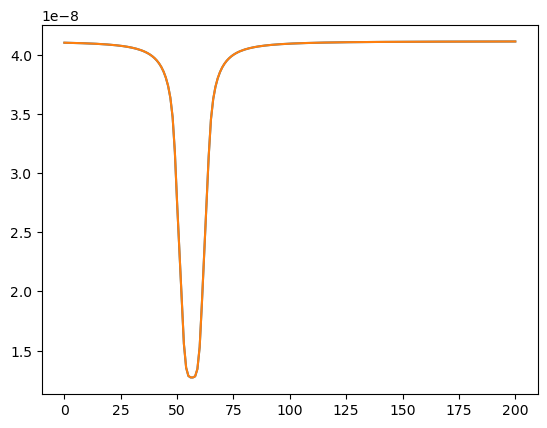

In [30]:
idz = -1
plt.plot(Ip[1000][0,idz])
plt.plot(I0[1000][0,idz])
plt.show()

In [31]:
dI = {}
for B in [0, 1000, 3000]:    
    dI[B] = np.loadtxt(f"dI_B{B:05d}G_nodiffuse.txt").T.reshape(4, nz, nw, order="F")
# dI = np.loadtxt("dI.txt").T.reshape(4, nz, nw, order="F")
# dI = np.loadtxt("dI_B1000G_diffuse.txt").T.reshape(4, nz, nw, order="F")
# dI[1000].shape

/tmp/ipykernel_2460008/102142189.py:23: RuntimeWarning: divide by zero encountered in log10
  diff = np.log10(np.abs(diff))


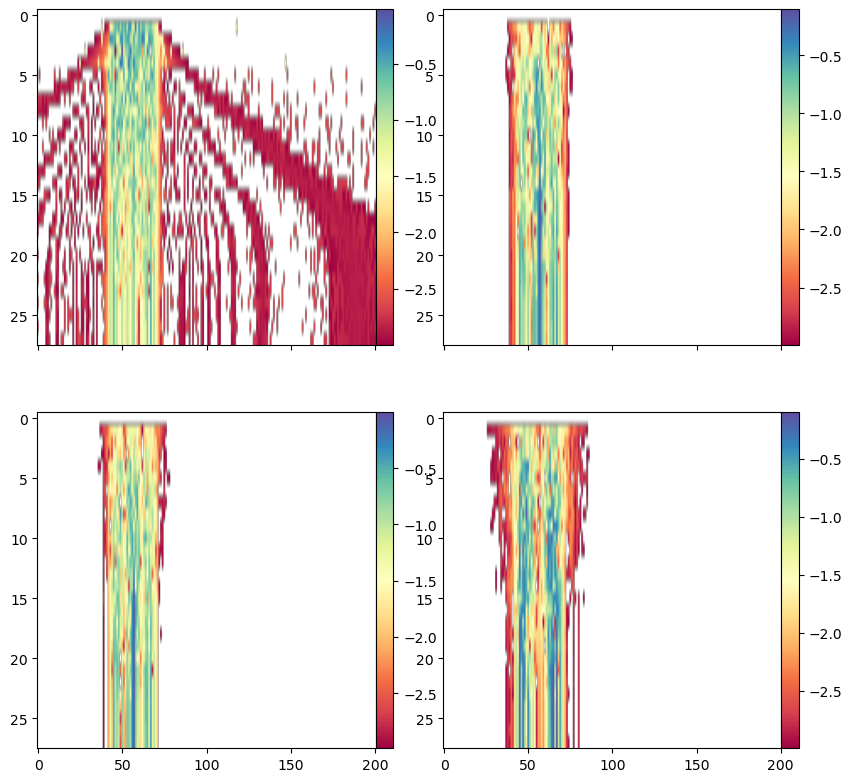

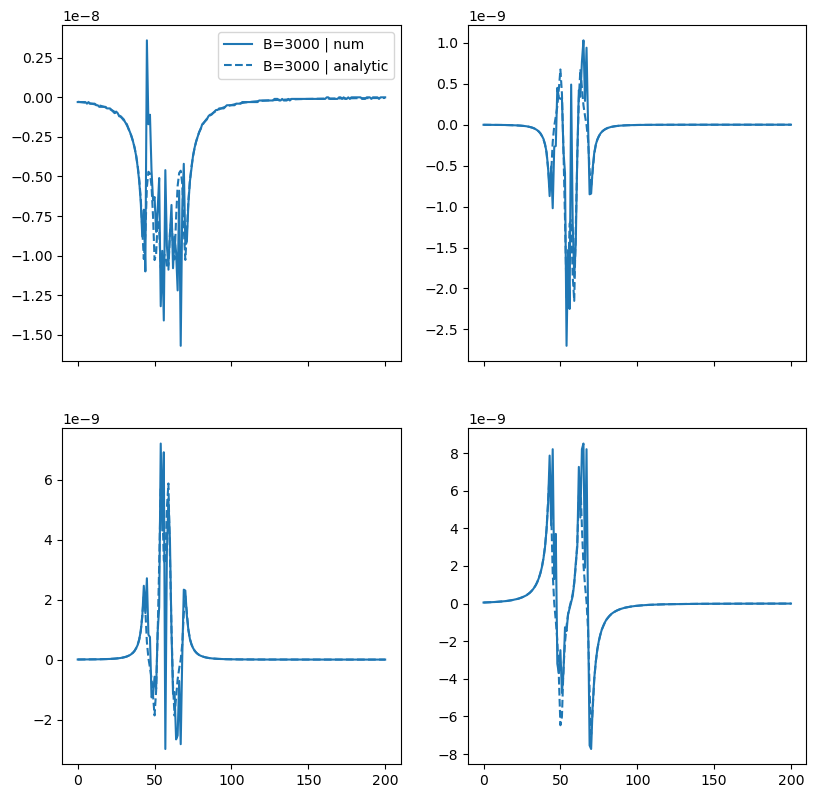

In [ ]:
idz = -1

fig, axs = plt.subplots(nrows=2, ncols=2, sharex=True, figsize=mpl.figure.figaspect(1)*2)
axs = axs.ravel()

fig2, axs2 = plt.subplots(nrows=2, ncols=2, sharex=True, figsize=mpl.figure.figaspect(1)*2)
axs2 = axs2.ravel()

# ylim = [(-0.4, 0.01), (-0.05, 0.04), (-0.02, 0.01), (-0.2, 0.2)]

for idb, B in enumerate([3000]):
    for ids in range(4):
        RF = Ip[B][ids] - I0[B][ids]
        RF /= 1e-3
        
        axs2[ids].plot(RF[idz], label=f"B={B} | num", c=f"C{idb}")
        axs2[ids].plot(dI[B][ids,idz], c=f"C{idb}", ls="--", label=f"B={B} | analytic")
        # axs[ids].set_ylim(ylim[ids])
        # axs[ids].set_xlim((0,100))

        diff = (RF - dI[B][ids])
        diff /= np.max(np.abs(RF))
        diff = np.log10(np.abs(diff))
        diff[diff<-3] = np.nan
        im = axs[ids].imshow(diff, aspect="auto", cmap="Spectral")
        add_colorbar(fig, axs[ids], im)

axs2[0].legend()
plt.show()

The difference is somewhere in opacity and emissivity. It looks like a profile, and it depends on the B. The profiles are consistent no matter what is the B. 

In [17]:
chi0 = {}
eta0 = {}
chi = {}
eta = {}
for B in [0, 1000, 3000]:
    chi0[B] = np.loadtxt(f"chi_nonperturbed_B{B:05d}G.txt").T#.reshape(nz, 4, nw, order="C")
    print(chi0[B].shape)
    eta0[B] = np.loadtxt(f"eta_nonperturbed_B{B:05d}G.txt").T#.reshape(nz, 4, nw, order="C")
    chi[B] = np.loadtxt(f"chi_perturbed_B{B:05d}G.txt").T#.reshape(nz, 4, nw, order="C")
    eta[B] = np.loadtxt(f"eta_perturbed_B{B:05d}G.txt").T#.reshape(nz, 4, nw, order="C")

(112, 201)
(112, 201)
(112, 201)


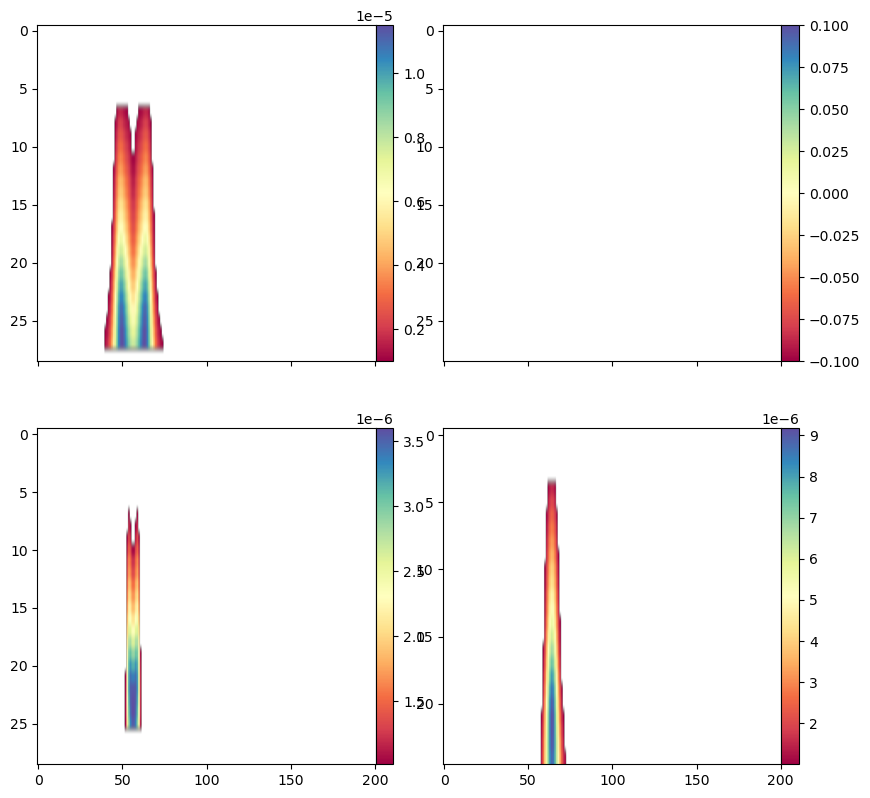

In [18]:
idz = slice(0, None)
idw = slice(0, None)

fig, axs = plt.subplots(nrows=2, ncols=2, sharex=True, figsize=mpl.figure.figaspect(1)*2)
axs = axs.ravel()

B = 3000
nz = 29

diff = chi[B] - chi0[B]
norm = np.max(np.abs(diff))
diff -= chi0[B]*np.log(10)*1e-5
# diff -= 1
# diff *= 100

l = 0
for ids in range(4):
    u = (ids+1)*nz

    img = diff[l:u]/norm#np.abs(np.max((diff[l:u])))

    # print(np.min(img), np.max(img))
    
    img[img<1e-6] = np.nan
    im = axs[ids].imshow(img, aspect="auto", cmap="Spectral")
    add_colorbar(fig, axs[ids], im)
    l = u

plt.show()